<a href="https://colab.research.google.com/github/UDHISRI/DAV_LAB_OUTPUT/blob/main/3B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UCI Diabetes Dataset Sample:

   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      182            105             40      224  34.408414   
1      131            112             10       31  22.407901   
2      172             65             12      142  37.098702   
3       94             94             25      265  33.728329   
4      186            119             32      193  30.380506   

   DiabetesPedigreeFunction  Age  Outcome  
0                  0.439067   56        1  
1                  0.608758   23        1  
2                  2.064964   49        1  
3                  0.874067   25        0  
4                  0.154945   65        1  

Pima Indians Diabetes Dataset Sample:

   Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      182            105             40      224  34.408414   
1      131            112             10       31  22.407901   
2      172             65             12      142  37.098702   
3       94             94

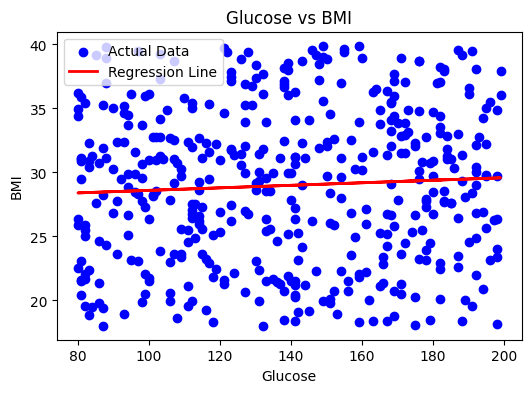


Linear Regression (Glucose -> BMI)
R2 Score : 0.0034


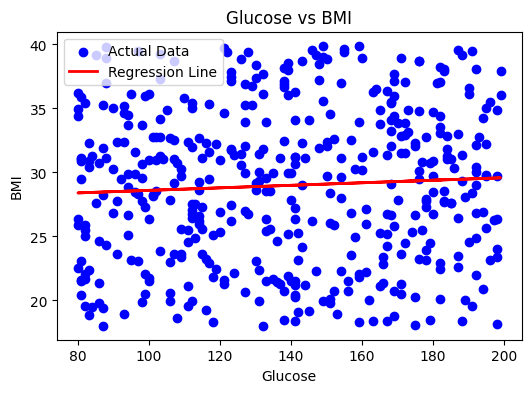


Logistic Regression
Accuracy Score : 1.0000

Logistic Regression
Accuracy Score : 1.0000


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# ---------------------------------------------
# Create UCI Diabetes Dataset
# ---------------------------------------------
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

# Create required columns
np.random.seed(42)

df["Glucose"] = np.random.randint(80, 200, len(df))
df["BloodPressure"] = np.random.randint(60, 120, len(df))
df["SkinThickness"] = np.random.randint(10, 50, len(df))
df["Insulin"] = np.random.randint(15, 300, len(df))
df["BMI"] = np.random.uniform(18, 40, len(df))
df["DiabetesPedigreeFunction"] = np.random.uniform(0.1, 2.5, len(df))
df["Age"] = np.random.randint(20, 80, len(df))

# Create Outcome column
df["Outcome"] = (df["Glucose"] > 125).astype(int)

# Keep only required columns
df = df[
    [
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
        "Outcome",
    ]
]

# Create two datasets
uci_diabetes = df.copy()
pima_diabetes = df.copy()

# ---------------------------------------------
# Display Dataset Samples
# ---------------------------------------------
print("UCI Diabetes Dataset Sample:\n")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:\n")
print(pima_diabetes.head())

# ---------------------------------------------
# Linear Regression
# ---------------------------------------------
def linear_regression_analysis(df, x_column, y_column):

    X = df[[x_column]]
    Y = df[y_column]

    model = LinearRegression()
    model.fit(X, Y)

    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression ({x_column} -> {y_column})")
    print(f"R2 Score : {r2:.4f}")

    plt.figure(figsize=(6,4))
    plt.scatter(X, Y, color="blue", label="Actual Data")
    plt.plot(X, Y_pred, color="red", linewidth=2, label="Regression Line")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{x_column} vs {y_column}")
    plt.legend()
    plt.show()

# Run Linear Regression
linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

# ---------------------------------------------
# Logistic Regression
# ---------------------------------------------
def logistic_regression_analysis(df, features, target):

    X = df[features]
    Y = df[target]

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)

    print("\nLogistic Regression")
    print(f"Accuracy Score : {accuracy:.4f}")

features = [
    "Glucose",
    "BloodPressure",
    "BMI",
    "Age"
]

target = "Outcome"

# Run Logistic Regression
logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)